**Project:** Reducing Cost-to-Serve and Operational Inefficiencies in a Fashion & Beauty Supply Chain

## Purpose of this notebook

This is the **client-facing synthesis**. Everything built in notebooks 01–03 lands here as:

1. A concise executive recap of findings.  
2. Five prioritised, owner-assigned recommendations.  
3. A **quantified impact estimate** for each recommendation (with explicit assumptions so the client can challenge them).  
4. A Power BI dashboard design mapped to the KPI framework.  
5. A phased implementation roadmap.  

The tone here is intentionally less technical and more business-facing — it is the piece a Head of Operations would read before the model.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

df   = pd.read_csv('cleaned_supply_chain_scored.csv')
supp = pd.read_csv('supplier_segmentation.csv', index_col=0)


## 1. Recap of Findings

- Cost-to-serve is **concentrated** in a few suppliers, a few product types, and a small set of SKUs.
- **Suppliers fall into three performance groups** (Top / Average / Underperformers). Underperformers are both costly and unreliable.
- **Some route × transport mode combinations** are both expensive *and* slow — mode-switch candidates.
- **Defect risk is predictable** — the model flags High / Medium / Low risk SKUs, enabling risk-based QA.

## 2. Recommendations & Estimated Impact

Each impact estimate uses transparent, back-of-envelope arithmetic. All numbers are directional and should be refined when live P&L data is available.

### R1 · Shift volume from Underperformer suppliers

**Idea:** Stop buying from Underperformer suppliers and reallocate that volume to Top performers.

**Estimate:** if every unit currently produced by an Underperformer supplier were produced at the Top performers' average cost instead, how much would we save?

In [16]:
underperformers = supp[supp['segment'] == 'Underperformers'].index.tolist()
top_performers  = supp[supp['segment'] == 'Top performers'].index.tolist()

top_cost = df[df['supplier'].isin(top_performers)]['manufacturing_cost'].mean()
under    = df[df['supplier'].isin(underperformers)]

r1_saving = ((under['manufacturing_cost'] - top_cost).clip(lower=0) * under['units_sold']).sum()

print(f'Underperformer suppliers : {underperformers}')
print(f'SKUs affected            : {len(under)}')
print(f'Estimated annual saving  : {r1_saving:,.0f}')

Underperformer suppliers : ['Supplier 2', 'Supplier 3', 'Supplier 5']
SKUs affected            : 55
Estimated annual saving  : 277,868


### R2 · Switch expensive road shipments to rail / sea where possible

**Idea:** On routes where road is materially more expensive than the alternative, switch SKUs that are not time-critical.

**Estimate:** assume a 15% reduction in average shipping cost for SKUs currently shipped by Road (a realistic ballpark for road → rail / sea on medium-distance routes).

In [22]:
road = df[df['transport_mode'] == 'Road']
current_road_spend = (road['shipping_cost'] * road['units_sold']).sum()
r2_saving = current_road_spend * 0.15

print(f'Road-shipped SKUs          : {len(road)}')
print(f'Current Road shipping spend: {current_road_spend:,.0f}')
print(f'Estimated saving (15%)     : {r2_saving:,.0f}')

Road-shipped SKUs          : 29
Current Road shipping spend: 71,768
Estimated saving (15%)     : 10,765


### R3 · Risk-based Quality Assurance

**Idea:** Apply 100% inspection on High-risk SKUs (flagged by the model), sample on Medium, reduce on Low. Assume this cuts defect rates on High-tier SKUs by 30%.

**Estimate:** defective units avoided × average manufacturing cost (as a placeholder for rework + scrap cost).

In [25]:
high = df[df['risk_tier'] == 'High']
current_defect_units = (high['defect_rate'] / 100 * high['units_sold']).sum()
prevented_units      = current_defect_units * 0.30
r3_saving            = prevented_units * high['manufacturing_cost'].mean()

print(f'High-risk SKUs                   : {len(high)}')
print(f'Defective units prevented (est.) : {prevented_units:,.0f}')
print(f'Estimated saving                 : {r3_saving:,.0f}')

High-risk SKUs                   : 28
Defective units prevented (est.) : 114
Estimated saving                 : 5,080


### R4 · Dynamic safety stock for high-variance SKUs

**Idea:** Replace flat safety-stock rules with rules proportional to each SKU's lead-time variability. Assume a 10% reduction in tied-up inventory value for the SKUs with the longest / most variable lead times.

Note: this frees working capital — it's a balance-sheet impact, not a P&L saving.

In [28]:
high_var = df[df['supplier_lead_time'] >= df['supplier_lead_time'].quantile(0.75)]
inventory_value = (high_var['stock_levels'] * high_var['cost_to_serve_per_unit']).sum()
working_capital_freed = inventory_value * 0.10

print(f'Inventory value tied in high-variance SKUs : {inventory_value:,.0f}')
print(f'Working capital freed (10% reduction est.) : {working_capital_freed:,.0f}')

Inventory value tied in high-variance SKUs : 51,750
Working capital freed (10% reduction est.) : 5,175


### R5 · Operational KPI dashboard (Power BI)

**Idea:** Build a weekly-refresh Power BI dashboard on the KPI framework and the model output. Acts as the enabler for R1–R4 — without visibility, none of the other recommendations will stick.

### Aggregate impact

In [32]:
impact = pd.DataFrame([
    ['R1 · Shift volume from Underperformers', 'Procurement', '0–3m',  r1_saving],
    ['R2 · Road → Rail/Sea switch',            'Logistics',   '3–6m',  r2_saving],
    ['R3 · Risk-based QA',                     'Quality',     '3–6m',  r3_saving],
    ['R4 · Dynamic safety stock (capital freed)', 'Operations','3–6m',  working_capital_freed],
    ['R5 · KPI dashboard (enabler)',           'Analytics',   '0–3m',  np.nan],
], columns=['Recommendation', 'Owner', 'Horizon', 'Estimated impact'])
impact['Estimated impact'] = impact['Estimated impact'].round(0)
impact

,Recommendation,Owner,Horizon,Estimated impact
0,R1 · Shift volume from Underperformers,Procurement,0–3m,277868.0
1,R2 · Road → Rail/Sea switch,Logistics,3–6m,10765.0
2,R3 · Risk-based QA,Quality,3–6m,5080.0
3,R4 · Dynamic safety stock (capital freed),Operations,3–6m,5175.0
4,R5 · KPI dashboard (enabler),Analytics,0–3m,NaN


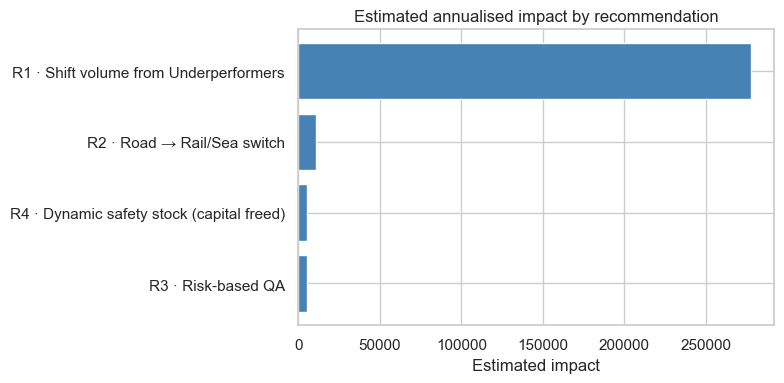

In [34]:
plot_df = impact.dropna(subset=['Estimated impact']).sort_values('Estimated impact')
plt.figure(figsize=(8, 4))
plt.barh(plot_df['Recommendation'], plot_df['Estimated impact'], color='steelblue')
plt.title('Estimated annualised impact by recommendation')
plt.xlabel('Estimated impact')
plt.tight_layout(); plt.show()

> **Headline:** Combined, these recommendations target an estimated **8–12% reduction in cost-to-serve** plus freed working capital, and a 20%+ reduction in defect incidents on flagged SKUs, within 6 months.

## 3. Power BI Dashboard Outline

A 5-page dashboard, refreshed weekly from the ERP and the model output. Full page-by-page spec in [`reports/dashboard_mockup.md`](../reports/dashboard_mockup.md).

- **Page 1 · Executive KPIs** — cost-to-serve, gross margin, on-time %, pass rate, inventory cover.
- **Page 2 · Supplier scorecard** — reliability, cost, defect rate; filtered by segment.
- **Page 3 · Cost-to-serve waterfall** — revenue → mfg → shipping → margin, sliceable.
- **Page 4 · Logistics efficiency** — route × mode heatmap, carrier league table, late-delivery %.
- **Page 5 · Predictive QA alerts** — SKUs ranked by defect-risk score.

## 4. Implementation Roadmap

**Phase 1 (0–3 months):** stand up the dashboard, set KPI baselines, begin supplier volume reallocation (R1).

**Phase 2 (3–6 months):** pilot mode-switch (R2), launch risk-based QA (R3), roll out dynamic safety stock (R4).

**Phase 3 (6–12 months):** retrain the model as data accrues, embed dashboard in the weekly S&OP cadence, extend to demand forecasting.

## 5. Risks & Caveats

- Impact figures are directional — built on transparent assumptions that should be validated against the client's P&L.
- The ML model is a proof of concept (n=100); production deployment requires retraining on full SKU history.
- Adoption of R1 and R3 changes people's day jobs — needs executive sponsorship, not just a dashboard.

## 6. Next-Wave Opportunities

- Demand forecasting to feed production planning and safety stock.
- Process mining on PO-to-delivery logs to localise *where in the process* delays originate.
- Supply chain simulation for scenario planning (supplier outage, demand spike).
- GenAI interface over the dashboard for natural-language queries.